# TSIL Demo: A Tiny Maze

This CPU-only notebook is a compact mechanism demo for Temporal Self-Imitation Learning (TSIL). It uses a small synthetic maze to show how adaptive temporal targeting and fast-success replay can guide policy learning toward efficient task completion. For the full method, benchmark setup, and full benchmark results, please refer to our paper.

Notebook flow:

1. Setup
2. Maze Environment
3. Analytical Return Check
4. TSIL Mini Implementations
5. PPO Mini Implementations
6. Training
7. Learned Behavior
8. Evaluation Curves
9. Questions & Answers

## 1. Setup

Run this cell first in Colab or a fresh local notebook. The demo requires Python 3.8 or newer; Colab's default Python runtime is sufficient. The installer only downloads packages that are missing from the current runtime.

In [11]:
import importlib.util
import subprocess
import sys

if sys.version_info < (3, 8):
    raise RuntimeError("This notebook requires Python 3.8 or newer.")

required_packages = {
    "numpy": "numpy",
    "torch": "torch",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
    "gymnasium": "gymnasium",
}
missing = [pip_name for import_name, pip_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print(f"Python {sys.version.split()[0]} ready; installed missing packages: {missing or 'none'}")

Python 3.8.12 ready; installed missing packages: none


In [12]:
import base64
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
from gymnasium import spaces
from IPython.display import HTML

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
from matplotlib import animation
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.distributions import Categorical

torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

## 2. Maze Environment

The start is the top-left cell and the goal is the bottom-right cell. The only guidance reward is the center cell `(3, 3)`, so the reward is spatially sparse.

Plain PPO sees only `[row, col, 0, 0]` and receives only task reward. PPO+TSIL sees raw `[row, col, t_used, t_target]` and receives the paper-style terminal reward decomposition: base task success reward plus the extra temporal success term $r_{\mathrm{succ}}\min(t_{\mathrm{target}} / t_{\mathrm{used}}, 1)$.

In [13]:
@dataclass
class DemoConfig:
    height: int = 7                 # Grid rows; start is top-left, goal is bottom-right.
    width: int = 7                  # Grid columns.
    max_steps: int = 30             # Artificial time limit; timeout is truncation, not termination.
    gamma: float = 0.98             # Discount factor for PPO returns and TSIL replay returns.
    dense_reward: float = 0.02      # Sparse center-cell bait reward collected by staying in the middle.
    success_reward: float = 0.1     # Base task success reward; TSIL adds the temporal success bonus on top.
    
    iters: int = 100                # PPO iterations; increase for smoother curves, decrease for faster runs.
    rollout_steps: int = 1024       # Target number of rollout transitions collected before each PPO update.
    update_epochs: int = 3          # PPO passes over the collected rollout batch.
    minibatch_size: int = 128       # PPO minibatch size for rollout transitions.
    lr: float = 2.5e-3              # Adam learning rate for the shared actor-critic network.
    clip_coef: float = 0.2          # PPO probability-ratio clipping range.
    vf_coef: float = 0.5            # Weight on the PPO value-function loss.
    ent_coef: float = 0.02          # Entropy bonus weight; keeps early exploration alive.
    
    sil_coef: float = 0.05          # Weight on the TSIL replay loss added to PPO.
    sil_vf_coef: float = 0.5        # Value-loss weight inside the TSIL positive-gap replay loss.
    sil_topk: int = 5               # Archive capacity for fast-success trajectories and pre-success return fallback.
    sil_batch_size: int = 128       # Approximate transition budget drawn from TSIL replay each update.
    sil_sample_unit: str = "trajectory"  # Demo uses whole-trajectory replay to keep temporal relabeling clear.
    sil_normalize_gap: bool = True        # Normalize positive advantage gaps before weighting replay policy loss.


ACTIONS = ("right", "left", "up", "down", "stay")


class MazeEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, cfg, use_temporal_bonus=True, mask_temporal=False):
        super().__init__()
        self.cfg = cfg
        self.use_temporal_bonus = bool(use_temporal_bonus)
        self.mask_temporal = bool(mask_temporal)
        self.start = (0, 0)
        self.goal = (cfg.height - 1, cfg.width - 1)
        self.bait_cells = {(cfg.height // 2, cfg.width // 2)}
        self.action_space = spaces.Discrete(len(ACTIONS))
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0], dtype=np.float32),
            high=np.array([cfg.height - 1, cfg.width - 1, cfg.max_steps, cfg.max_steps], dtype=np.float32),
            dtype=np.float32,
        )
        self.t_target = float(cfg.max_steps)
        self.row, self.col, self.t_used = 0, 0, 0

    def set_t_target(self, t_target):
        self.t_target = float(t_target)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.row, self.col = self.start
        self.t_used = 0
        return self._obs(), {}

    def _obs(self):
        t_used = 0.0 if self.mask_temporal else float(self.t_used)
        t_target = 0.0 if self.mask_temporal else float(self.t_target)
        return np.array([self.row, self.col, t_used, t_target], dtype=np.float32)

    def _task_reward(self, success):
        dense = self.cfg.dense_reward if (self.row, self.col) in self.bait_cells else 0.0
        sparse = self.cfg.success_reward if success else 0.0
        return dense + sparse, dense, sparse

    def temporal_bonus(self, success, eps_time=None, t_target=None):
        if not (self.use_temporal_bonus and success):
            return 0.0
        eps_time = max(float(self.t_used if eps_time is None else eps_time), 1.0)
        t_target = float(self.t_target if t_target is None else t_target)
        return self.cfg.success_reward * min(max(t_target / eps_time, 0.0), 1.0)

    def step(self, action):
        if action == 0:
            self.col = min(self.cfg.width - 1, self.col + 1)
        elif action == 1:
            self.col = max(0, self.col - 1)
        elif action == 2:
            self.row = max(0, self.row - 1)
        elif action == 3:
            self.row = min(self.cfg.height - 1, self.row + 1)
        elif action == 4:
            pass
        else:
            raise ValueError(f"Unknown action: {action}")

        self.t_used += 1
        success = (self.row, self.col) == self.goal
        task_reward, dense_reward, sparse_reward = self._task_reward(success)
        temporal_bonus = self.temporal_bonus(success)
        reward = task_reward + temporal_bonus
        terminated = bool(success)
        truncated = bool(self.t_used >= self.cfg.max_steps and not terminated)
        info = {
            "success": bool(success),
            "eps_time": int(self.t_used),
            "t_used": int(self.t_used),
            "t_target": float(self.t_target),
            "dense_reward": float(dense_reward),
            "sparse_reward": float(sparse_reward),
            "task_reward": float(task_reward),
            "temporal_bonus": float(temporal_bonus),
        }
        return self._obs(), float(reward), terminated, truncated, info


cfg = DemoConfig()
print(f"Observation space: {MazeEnv(cfg).observation_space}")
print(f"Action space: {MazeEnv(cfg).action_space}")

Observation space: Box(0.0, [ 6.  6. 30. 30.], (4,), float32)
Action space: Discrete(5)


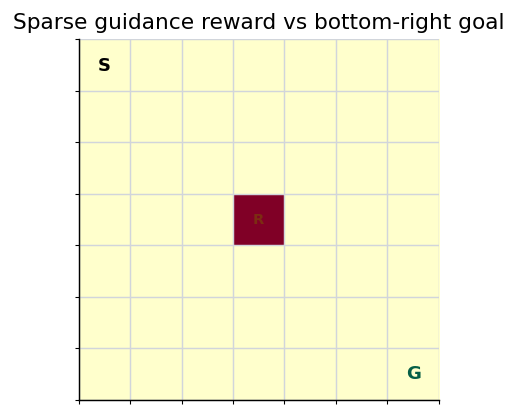

In [14]:
def draw_maze(ax, cfg, path=None, title=None):
    env = MazeEnv(cfg)
    grid = np.zeros((cfg.height, cfg.width), dtype=float)
    for row, col in env.bait_cells:
        grid[row, col] = cfg.dense_reward
    ax.imshow(grid, cmap="YlOrRd", vmin=0.0, vmax=cfg.dense_reward)
    ax.set_xticks(np.arange(-0.5, cfg.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cfg.height, 1), minor=True)
    ax.grid(which="minor", color="#d1d5db", linewidth=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0, 0, "S", ha="center", va="center", weight="bold")
    ax.text(cfg.width - 1, cfg.height - 1, "G", ha="center", va="center", weight="bold", color="#065f46")
    for row, col in env.bait_cells:
        ax.text(col, row, "R", ha="center", va="center", color="#7c2d12", fontsize=8, weight="bold")
    if path:
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        ax.plot(cols, rows, color="#111827", linewidth=2, marker="o", markersize=4)
    if title:
        ax.set_title(title)


fig, ax = plt.subplots(figsize=(3.6, 3.6))
draw_maze(ax, cfg, title="Sparse guidance reward vs bottom-right goal")
plt.show()

## 3. Analytical Return Check: Guidance Reward Can Dominate

Before training, we can inspect the scalar returns induced by this tiny maze. The ordinary PPO task return is

$$
G_{\mathrm{PPO}}
=
\sum_{t=1}^{\infty}\gamma^{t-1}
\left(
    r_d\mathbf{1}\{s_t=c\}
    +
    r_{\mathrm{succ}}\mathbf{1}\{s_t=g\}
\right),
$$

where $c$ is the center guidance-reward cell and $g$ is the goal. The TSIL rollout reward adds the terminal temporal bonus

$$
G_{\mathrm{TSIL}}
=
\sum_{t=1}^{\infty}\gamma^{t-1}
\left(
    r_d\mathbf{1}\{s_t=c\}
    +
    r_{\mathrm{succ}}\mathbf{1}\{s_t=g\}
    +
    r_{\mathrm{succ}}
    \min\left(\frac{t_{\mathrm{target}}}{t_{\mathrm{used}}}, 1\right)
    \mathbf{1}\{s_t=g\}
\right).
$$

The center guidance reward is useful because it points the agent toward the goal region. But if the policy only maximizes scalar return, repeatedly collecting that guidance reward can dominate the return. For both methods, reaching the center at time $T_c$ and staying there forever gives

$$
G_{\mathrm{center}}
=
 r_d\frac{\gamma^{T_c-1}}{1-\gamma}.
$$

The fastest successful trajectory reaches the goal at time $T_{\min}$ and passes through the center once:

$$
G_{\mathrm{fast}}^{\mathrm{PPO}}
=
 r_d\gamma^{T_c-1}
 +
 r_{\mathrm{succ}}\gamma^{T_{\min}-1},
$$

$$
G_{\mathrm{fast}}^{\mathrm{TSIL}}
=
 r_d\gamma^{T_c-1}
 +
 r_{\mathrm{succ}}\gamma^{T_{\min}-1}
 \left[
 1+
 \min\left(\frac{t_{\mathrm{target}}}{T_{\min}}, 1\right)
 \right].
$$

This makes the toy example nontrivial: the scalar reward can favor repeatedly collecting the center guidance reward, while the desired behavior is efficient task completion.

gamma=0.98, r_d=0.02, r_succ=0.1
T_c=6, T_min=12, t_target=12
Center-guidance infinite return: 0.904
Fast-success PPO return:     0.098
Fast-success TSIL return:    0.178


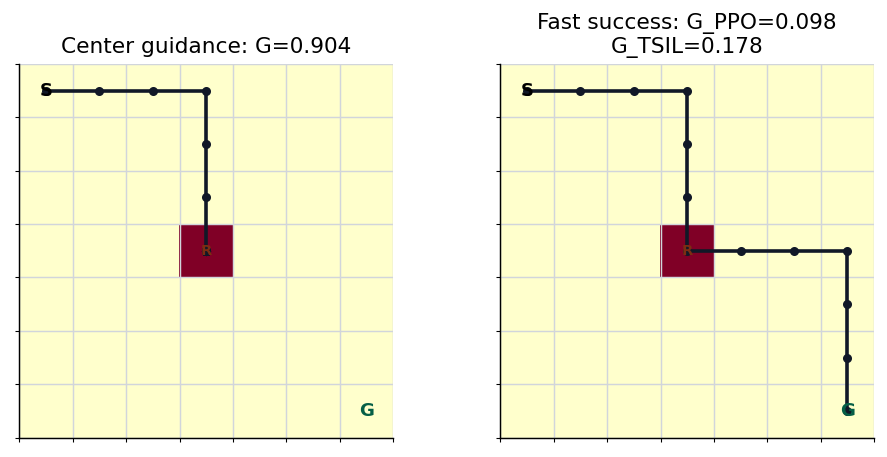

In [15]:
def center_guidance_path(cfg, horizon=None):
    horizon = cfg.max_steps if horizon is None else int(horizon)
    center = (cfg.height // 2, cfg.width // 2)
    row, col = 0, 0
    path = [(row, col)]
    while col < center[1]:
        col += 1
        path.append((row, col))
    while row < center[0]:
        row += 1
        path.append((row, col))
    while len(path) <= horizon:
        path.append(center)
    return path


def fast_success_path(cfg):
    center = (cfg.height // 2, cfg.width // 2)
    goal = (cfg.height - 1, cfg.width - 1)
    row, col = 0, 0
    path = [(row, col)]
    for target_row, target_col in (center, goal):
        while col < target_col:
            col += 1
            path.append((row, col))
        while row < target_row:
            row += 1
            path.append((row, col))
    return path


def analytical_returns(cfg, t_target=None):
    t_center = cfg.height // 2 + cfg.width // 2
    t_fast = (cfg.height - 1) + (cfg.width - 1)
    t_target = float(t_fast if t_target is None else t_target)
    dense_once = cfg.dense_reward * cfg.gamma ** (t_center - 1)
    success_once = cfg.success_reward * cfg.gamma ** (t_fast - 1)
    center_return = cfg.dense_reward * cfg.gamma ** (t_center - 1) / (1.0 - cfg.gamma)
    fast_ppo_return = dense_once + success_once
    fast_tsil_return = dense_once + success_once * (1.0 + min(t_target / float(t_fast), 1.0))
    return {
        "T_c": t_center,
        "T_min": t_fast,
        "t_target": t_target,
        "center_return": center_return,
        "fast_ppo_return": fast_ppo_return,
        "fast_tsil_return": fast_tsil_return,
    }


returns = analytical_returns(cfg)
print(f"gamma={cfg.gamma}, r_d={cfg.dense_reward}, r_succ={cfg.success_reward}")
print(f"T_c={returns['T_c']}, T_min={returns['T_min']}, t_target={returns['t_target']:.0f}")
print(f"Center-guidance infinite return: {returns['center_return']:.3f}")
print(f"Fast-success PPO return:     {returns['fast_ppo_return']:.3f}")
print(f"Fast-success TSIL return:    {returns['fast_tsil_return']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.4), constrained_layout=True)
draw_maze(axes[0], cfg, center_guidance_path(cfg), f"Center guidance: G={returns['center_return']:.3f}")
draw_maze(axes[1], cfg, fast_success_path(cfg), f"Fast success: G_PPO={returns['fast_ppo_return']:.3f}\nG_TSIL={returns['fast_tsil_return']:.3f}")
plt.show()


The analytical check sets up the tension: the center guidance reward is helpful, but pure scalar-return optimization can still prefer repeatedly collecting it. Even after temporal reward shaping, the scalar-return optimum can remain a high-return guidance-reward behavior rather than the fastest successful behavior. TSIL adds adaptive temporal targeting and fast-success replay as learning signals for efficient task completion. What happens in actual training?

## 4. TSIL Mini Implementations

This block keeps the TSIL-specific pieces together: fast-success archive, return fallback before any success exists, fast-success self-imitation, temporal-target relabeling, advantage filtering, temporal efficency weightning, and adaptive temporal target update. For the detailed TSIL method and full algorithm, please refer to our paper.

In [16]:
# RL helpers shared by rollout PPO returns and TSIL replay returns.
def discounted_returns(rewards, terminateds=None, truncateds=None, bootstrap_values=None, gamma=1.0):
    n = len(rewards)
    terminateds = [False] * n if terminateds is None else terminateds
    truncateds = [False] * n if truncateds is None else truncateds
    bootstrap_values = [0.0] * n if bootstrap_values is None else bootstrap_values
    out = []
    running = 0.0
    for reward, terminated, truncated, bootstrap_value in zip(
        reversed(rewards), reversed(terminateds), reversed(truncateds), reversed(bootstrap_values)
    ):
        if terminated:
            running = 0.0
        elif truncated:
            running = float(bootstrap_value)
        running = float(reward) + gamma * running
        out.append(running)
    return torch.tensor(list(reversed(out)), dtype=torch.float32)


def s0_return(rewards, gamma, terminated=False, truncated=False, bootstrap_value=0.0):
    if not rewards:
        return 0.0
    terminateds = [False] * len(rewards)
    truncateds = [False] * len(rewards)
    bootstrap_values = [0.0] * len(rewards)
    terminateds[-1] = bool(terminated)
    truncateds[-1] = bool(truncated)
    bootstrap_values[-1] = float(bootstrap_value)
    return float(discounted_returns(rewards, terminateds, truncateds, bootstrap_values, gamma)[0])


class TsilTrajectoryMemory:
    def __init__(self, cfg):
        self.cfg = cfg
        self.records = []
        self.return_idx = []
        self.fast_success_idx = []

    def refresh_rankings(self):
        ids = list(range(len(self.records)))
        self.return_idx = sorted(ids, key=lambda i: self.records[i]["return_score"], reverse=True)[: self.cfg.sil_topk]
        successes = [i for i in ids if self.records[i]["success"]]
        self.fast_success_idx = sorted(successes, key=lambda i: self.records[i]["eps_time"])[: self.cfg.sil_topk]
        keep = sorted(set(self.return_idx + self.fast_success_idx))
        if len(keep) < len(self.records):
            self.records = [self.records[i] for i in keep]
            self.refresh_rankings()

    def add(self, episode, global_step):
        return_score = s0_return(
            episode["rewards"], self.cfg.gamma,
            terminated=episode.get("terminated", False),
            truncated=episode.get("truncated", False),
            bootstrap_value=episode.get("terminal_bootstrap_value", 0.0),
        )
        success = bool(episode["success"])
        eps_time = int(episode["eps_time"])
        admit = len(self.return_idx) < self.cfg.sil_topk
        if not admit:
            admit = return_score > min(self.records[i]["return_score"] for i in self.return_idx)
        if not admit and success:
            admit = len(self.fast_success_idx) < self.cfg.sil_topk or eps_time < max(self.records[i]["eps_time"] for i in self.fast_success_idx)
        if not admit:
            return False
        self.records.append({
            "obs": [np.asarray(obs, dtype=np.float32) for obs in episode["obs"]],
            "actions": list(episode["actions"]),
            "base_rewards": list(episode["base_rewards"]),
            "success": success,
            "eps_time": eps_time,
            "truncated": bool(episode.get("truncated", False)),
            "terminal_next_obs": np.asarray(episode.get("terminal_next_obs"), dtype=np.float32),
            "terminal_bootstrap_value": float(episode.get("terminal_bootstrap_value", 0.0)),
            "return_score": return_score,
            "global_step": int(global_step),
        })
        self.refresh_rankings()
        return True

    def temporal_bonus_for_record(self, record, t_target):
        if not record["success"]:
            return 0.0
        eps_time = max(float(record["eps_time"]), 1.0)
        return self.cfg.success_reward * min(max(float(t_target) / eps_time, 0.0), 1.0)

    def temporal_efficiency_weight_for_record(self, record, t_target):
        if not record["success"]:
            return 1.0
        eps_time = max(float(record["eps_time"]), 1.0)
        return 1.0 + min(max(float(t_target) / eps_time, 0.0), 1.0)

    def sample_trajectory_batch(self, t_target, model=None):
        success_ids = list(self.fast_success_idx)
        pool = success_ids if success_ids else list(self.return_idx)
        if not pool:
            return None

        avg_len = max(np.mean([len(self.records[i]["actions"]) for i in pool]), 1.0)
        traj_count = max(1, math.ceil(self.cfg.sil_batch_size / avg_len))
        chosen = random.choices(pool, k=traj_count)

        flat_count = sum(len(self.records[i]["actions"]) for i in chosen)
        obs, actions, returns, weights = [], [], [], []
        for idx in chosen:
            record = self.records[idx]
            rewards = list(record["base_rewards"])
            if record["success"] and rewards:
                rewards[-1] += self.temporal_bonus_for_record(record, t_target)

            bootstrap_value = 0.0
            if record["truncated"] and not record["success"] and model is not None:
                terminal_next_obs = np.asarray(record["terminal_next_obs"], dtype=np.float32).copy()
                terminal_next_obs[3] = float(t_target)
                with torch.no_grad():
                    _, value = model.dist_value(torch.tensor(terminal_next_obs, dtype=torch.float32).unsqueeze(0))
                bootstrap_value = float(value.item())

            terminateds = [False] * len(rewards)
            truncateds = [False] * len(rewards)
            bootstrap_values = [0.0] * len(rewards)
            terminateds[-1] = bool(record["success"])
            truncateds[-1] = bool(record["truncated"] and not record["success"])
            bootstrap_values[-1] = bootstrap_value
            record_returns = discounted_returns(rewards, terminateds, truncateds, bootstrap_values, self.cfg.gamma).tolist()

            traj_weight = self.temporal_efficiency_weight_for_record(record, t_target)
            step_scale = flat_count / (len(record["actions"]) * max(len(chosen), 1))
            for state, action, ret in zip(record["obs"], record["actions"], record_returns):
                relabeled = np.asarray(state, dtype=np.float32).copy()
                relabeled[3] = float(t_target)
                obs.append(relabeled)
                actions.append(action)
                returns.append(ret)
                weights.append(traj_weight * step_scale)

        return {
            "obs": torch.tensor(np.asarray(obs), dtype=torch.float32),
            "actions": torch.tensor(actions, dtype=torch.long),
            "returns": torch.tensor(returns, dtype=torch.float32),
            "weights": torch.tensor(weights, dtype=torch.float32),
        }

    def sil_archive_best_eps_time(self):
        return min([self.records[i]["eps_time"] for i in self.fast_success_idx], default=np.nan)

    def size(self):
        return len(self.records)


def target_update(t_target, episodes):
    success_times = [episode["eps_time"] for episode in episodes if episode["success"]]
    return min(float(t_target), float(min(success_times))) if success_times else float(t_target)


def compute_tsil_replay_loss(model, tsil_memory, cfg, t_target):
    batch = tsil_memory.sample_trajectory_batch(t_target, model=model)
    if batch is None:
        return torch.tensor(0.0), 0.0
    dist, values = model.dist_value(batch["obs"])
    log_prob = dist.log_prob(batch["actions"])
    positive_gap = torch.clamp(batch["returns"] - values, min=0.0)
    weights = positive_gap.detach() * batch["weights"]
    if cfg.sil_normalize_gap and bool((positive_gap > 0).any()):
        active = weights[weights > 0]
        if active.numel() > 0:
            weights = torch.where(weights > 0, torch.clamp(weights / (active.std(unbiased=False) + 1e-8), max=1.0), weights)
    policy_loss = -(weights * log_prob).mean()
    value_loss = 0.5 * (positive_gap ** 2).mean()
    return cfg.sil_coef * (policy_loss + cfg.sil_vf_coef * value_loss), float((positive_gap > 0).float().mean())

## 5. PPO Mini Implementations

This block contains the ordinary actor-critic model, rollout collection, PPO updates, and deterministic policy evaluation helpers. Each update collects complete episodes until a fixed rollout-step budget is reached, so PPO and PPO+TSIL use the same rollout-step budget per update. Goal success is a true termination; max-step timeout is a truncation and bootstraps from `V(next_obs)`.

In [17]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim=4, num_actions=5):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh())
        self.pi = nn.Linear(32, num_actions)
        self.v = nn.Linear(32, 1)

    def dist_value(self, obs):
        h = self.net(obs)
        return Categorical(logits=self.pi(h)), self.v(h).squeeze(-1)


def collect_rollouts(model, cfg, method, t_target):
    use_temporal = method == "PPO+TSIL"
    env = MazeEnv(cfg, use_temporal_bonus=use_temporal, mask_temporal=not use_temporal)
    env.set_t_target(t_target)
    steps, episodes = [], []
    while len(steps) < cfg.rollout_steps:
        obs, _ = env.reset()
        episode = {
            "obs": [], "actions": [], "rewards": [], "base_rewards": [],
            "success": False, "eps_time": cfg.max_steps, "dense_hits": 0,
            "terminated": False, "truncated": False, "terminal_next_obs": None,
            "terminal_bootstrap_value": 0.0,
        }
        done = False
        while not done:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                dist, value = model.dist_value(obs_tensor)
                action = dist.sample()
                log_prob = dist.log_prob(action)
            next_obs, reward, terminated, truncated, info = env.step(int(action))
            done = bool(terminated or truncated)
            bootstrap_value = 0.0
            if truncated:
                with torch.no_grad():
                    _, next_value = model.dist_value(torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0))
                bootstrap_value = float(next_value.item())
            steps.append((
                obs, int(action), float(log_prob), float(value), float(reward),
                bool(terminated), bool(truncated), bootstrap_value,
            ))
            episode["obs"].append(obs)
            episode["actions"].append(int(action))
            episode["rewards"].append(float(reward))
            episode["base_rewards"].append(float(info["task_reward"]))
            episode["dense_hits"] += int(info["dense_reward"] > 0.0)
            obs = next_obs
            if done:
                episode["success"] = bool(info["success"])
                episode["eps_time"] = int(info["eps_time"])
                episode["terminated"] = bool(terminated)
                episode["truncated"] = bool(truncated)
                episode["terminal_next_obs"] = np.asarray(next_obs, dtype=np.float32)
                episode["terminal_bootstrap_value"] = float(bootstrap_value)
        episodes.append(episode)
    return steps, episodes


def evaluate_policy(model, cfg, method, t_target):
    use_temporal = method == "PPO+TSIL"
    env = MazeEnv(cfg, use_temporal_bonus=use_temporal, mask_temporal=not use_temporal)
    env.set_t_target(t_target)
    obs, _ = env.reset()
    path = [(env.row, env.col)]
    dense_hits = 0
    policy_return = 0.0
    task_return = 0.0
    done = False
    discount = 1.0
    while not done:
        with torch.no_grad():
            dist, _ = model.dist_value(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
            action = int(torch.argmax(dist.logits, dim=-1))
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        policy_return += discount * float(reward)
        task_return += discount * float(info["task_reward"])
        discount *= cfg.gamma
        path.append((env.row, env.col))
        dense_hits += int(info["dense_reward"] > 0.0)
    return {
        "success": bool(info["success"]),
        "eps_time": int(info["eps_time"]),
        "path": path,
        "dense_hits": dense_hits,
        "dense_frac": dense_hits / max(len(path) - 1, 1),
        "policy_return": float(policy_return),
        "task_return": float(task_return),
    }


def train(method, seed, cfg):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = ActorCritic()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    tsil_memory = TsilTrajectoryMemory(cfg)
    t_target = float(cfg.max_steps)
    history = []
    global_step = 0

    for iteration in range(cfg.iters):
        steps, episodes = collect_rollouts(model, cfg, method, t_target)
        global_step += len(steps)
        if method == "PPO+TSIL":
            for episode in episodes:
                tsil_memory.add(episode, global_step)

        obs = torch.tensor(np.asarray([step[0] for step in steps]), dtype=torch.float32)
        actions = torch.tensor([step[1] for step in steps], dtype=torch.long)
        old_log_probs = torch.tensor([step[2] for step in steps], dtype=torch.float32)
        old_values = torch.tensor([step[3] for step in steps], dtype=torch.float32)
        returns = discounted_returns(
            [step[4] for step in steps],
            [step[5] for step in steps],
            [step[6] for step in steps],
            [step[7] for step in steps],
            cfg.gamma,
        )
        advantages = returns - old_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        positive_fracs = []
        indices = np.arange(len(steps))
        for _ in range(cfg.update_epochs):
            np.random.shuffle(indices)
            for start in range(0, len(indices), cfg.minibatch_size):
                mb = torch.tensor(indices[start : start + cfg.minibatch_size], dtype=torch.long)
                dist, values = model.dist_value(obs[mb])
                log_probs = dist.log_prob(actions[mb])
                ratio = torch.exp(log_probs - old_log_probs[mb])
                pg_loss = torch.max(
                    -advantages[mb] * ratio,
                    -advantages[mb] * torch.clamp(ratio, 1.0 - cfg.clip_coef, 1.0 + cfg.clip_coef),
                ).mean()
                value_loss = 0.5 * ((values - returns[mb]) ** 2).mean()
                loss = pg_loss + cfg.vf_coef * value_loss - cfg.ent_coef * dist.entropy().mean()
                if method == "PPO+TSIL":
                    replay_loss, positive_frac = compute_tsil_replay_loss(model, tsil_memory, cfg, t_target)
                    loss = loss + replay_loss
                    positive_fracs.append(positive_frac)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        successes = [episode["success"] for episode in episodes]
        success_times = [episode["eps_time"] for episode in episodes if episode["success"]]
        train_dense_frac = np.mean([episode["dense_hits"] / len(episode["actions"]) for episode in episodes])
        train_policy_return = np.mean([
            s0_return(
                episode["rewards"], cfg.gamma,
                terminated=episode["terminated"], truncated=episode["truncated"],
                bootstrap_value=episode["terminal_bootstrap_value"],
            )
            for episode in episodes
        ])
        train_task_return = np.mean([
            s0_return(
                episode["base_rewards"], cfg.gamma,
                terminated=episode["terminated"], truncated=episode["truncated"],
            )
            for episode in episodes
        ])
        eval_info = evaluate_policy(model, cfg, method, t_target)
        history.append({
            "iteration": iteration,
            "train_success": float(np.mean(successes)),
            "train_eps_time": float(np.mean(success_times)) if success_times else np.nan,
            "train_dense_frac": float(train_dense_frac),
            "train_policy_return": float(train_policy_return),
            "train_task_return": float(train_task_return),
            "eval_success": float(eval_info["success"]),
            "eval_eps_time": eval_info["eps_time"] if eval_info["success"] else np.nan,
            "eval_dense_frac": float(eval_info["dense_frac"]),
            "eval_dense_hits": eval_info["dense_hits"],
            "eval_policy_return": float(eval_info["policy_return"]),
            "eval_task_return": float(eval_info["task_return"]),
            "eval_path": eval_info["path"],
            "t_target": float(t_target),
            "sil_archive_best_eps_time": float(tsil_memory.sil_archive_best_eps_time()),
            "sil_archive_size": tsil_memory.size(),
            "replay_positive_frac": float(np.mean(positive_fracs)) if positive_fracs else np.nan,
        })

        if method == "PPO+TSIL":
            t_target = target_update(t_target, episodes)

    return {"method": method, "seed": seed, "model": model, "history": history, "tsil_memory": tsil_memory}

## 6. Training

In [18]:
# The training will take ~3mins on cpu in total with the default config.
METHODS = ("PPO", "PPO+TSIL")
SEEDS = (0, 1, 2)  # Increase to (0, 1, 2) for smoother aggregate curves.

runs = {method: [] for method in METHODS}
for method in METHODS:
    for seed in SEEDS:
        run = train(method, seed, cfg)
        runs[method].append(run)
        final = run["history"][-1]
        head_train = np.mean([entry["train_success"] for entry in run["history"][:10]])
        tail_train = np.mean([entry["train_success"] for entry in run["history"][-10:]])
        end = final["eval_path"][-1]
        print(
            f"{method:8s} seed={seed}: head_train={head_train:.3f}, "
            f"tail_train={tail_train:.3f}, eval_success={bool(final['eval_success'])}, "
            f"eval_time={final['eval_eps_time']}, eval_task_return={final['eval_task_return']:.3f}, "
            f"center_hits={final['eval_dense_hits']}, end={end}"
        )

PPO      seed=0: head_train=0.082, tail_train=0.000, eval_success=False, eval_time=nan, eval_task_return=0.358, center_hits=25, end=(3, 3)
PPO      seed=1: head_train=0.380, tail_train=0.000, eval_success=False, eval_time=nan, eval_task_return=0.358, center_hits=25, end=(3, 3)
PPO      seed=2: head_train=0.082, tail_train=0.000, eval_success=False, eval_time=nan, eval_task_return=0.358, center_hits=25, end=(3, 3)
PPO+TSIL seed=0: head_train=0.108, tail_train=1.000, eval_success=True, eval_time=12, eval_task_return=0.098, center_hits=1, end=(6, 6)
PPO+TSIL seed=1: head_train=0.461, tail_train=1.000, eval_success=True, eval_time=12, eval_task_return=0.098, center_hits=1, end=(6, 6)
PPO+TSIL seed=2: head_train=0.560, tail_train=1.000, eval_success=True, eval_time=12, eval_task_return=0.098, center_hits=1, end=(6, 6)


## 7. Learned Behavior

First inspect the final deterministic policies. The GIF makes the behavioral difference visible before we look at aggregate curves. The generated animation is saved to `/tmp/tsil_behavior.gif` and displayed inline.

Behavior GIF saved to: /tmp/tsil_behavior.gif



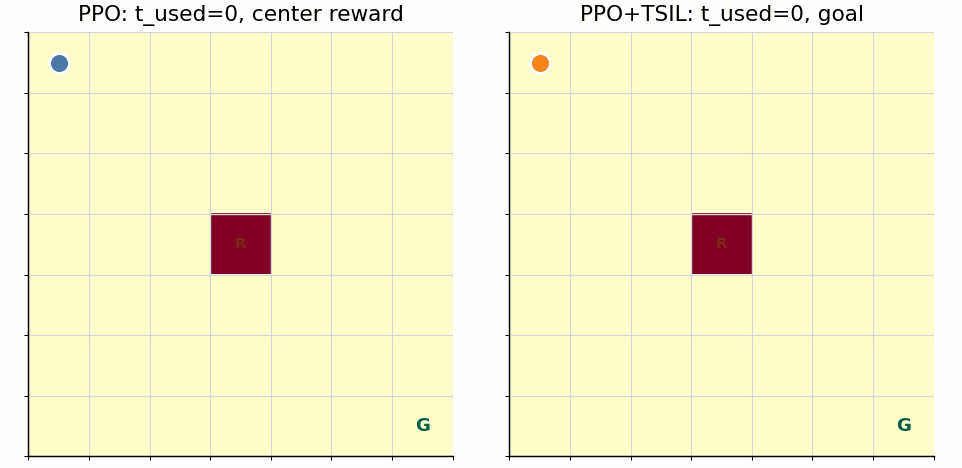

In [19]:
def behavior_gif(runs, cfg, seed_index=0, fps=3):
    finals = {method: runs[method][seed_index]["history"][-1] for method in METHODS}
    paths = {method: finals[method]["eval_path"] for method in METHODS}
    max_frames = max(len(path) for path in paths.values())
    colors = {"PPO": "#4c78a8", "PPO+TSIL": "#f58518"}

    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6), constrained_layout=True)

    def update(frame):
        artists = []
        for ax, method in zip(axes, METHODS):
            ax.clear()
            path = paths[method]
            last_idx = min(frame, len(path) - 1)
            shown = path[: last_idx + 1]
            status = "goal" if bool(finals[method]["eval_success"]) else "center reward"
            draw_maze(ax, cfg, shown, f"{method}: t_used={last_idx}, {status}")
            row, col = shown[-1]
            artists.append(ax.scatter([col], [row], s=120, color=colors[method], edgecolor="white", linewidth=1.5, zorder=5))
        return artists

    anim = animation.FuncAnimation(fig, update, frames=max_frames, interval=1000 / fps, blit=False)
    gif_path = Path("/tmp/tsil_behavior.gif")
    anim.save(gif_path, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    encoded = base64.b64encode(gif_path.read_bytes()).decode("ascii")
    print(f"Behavior GIF saved to: {gif_path}")
    return HTML(f'<img src="data:image/gif;base64,{encoded}" alt="TSIL behavior comparison GIF" />')


behavior_gif(runs, cfg, seed_index=0)

## 8. Evaluation Curves

Now use the summary plots to diagnose why the learned behaviors differ.

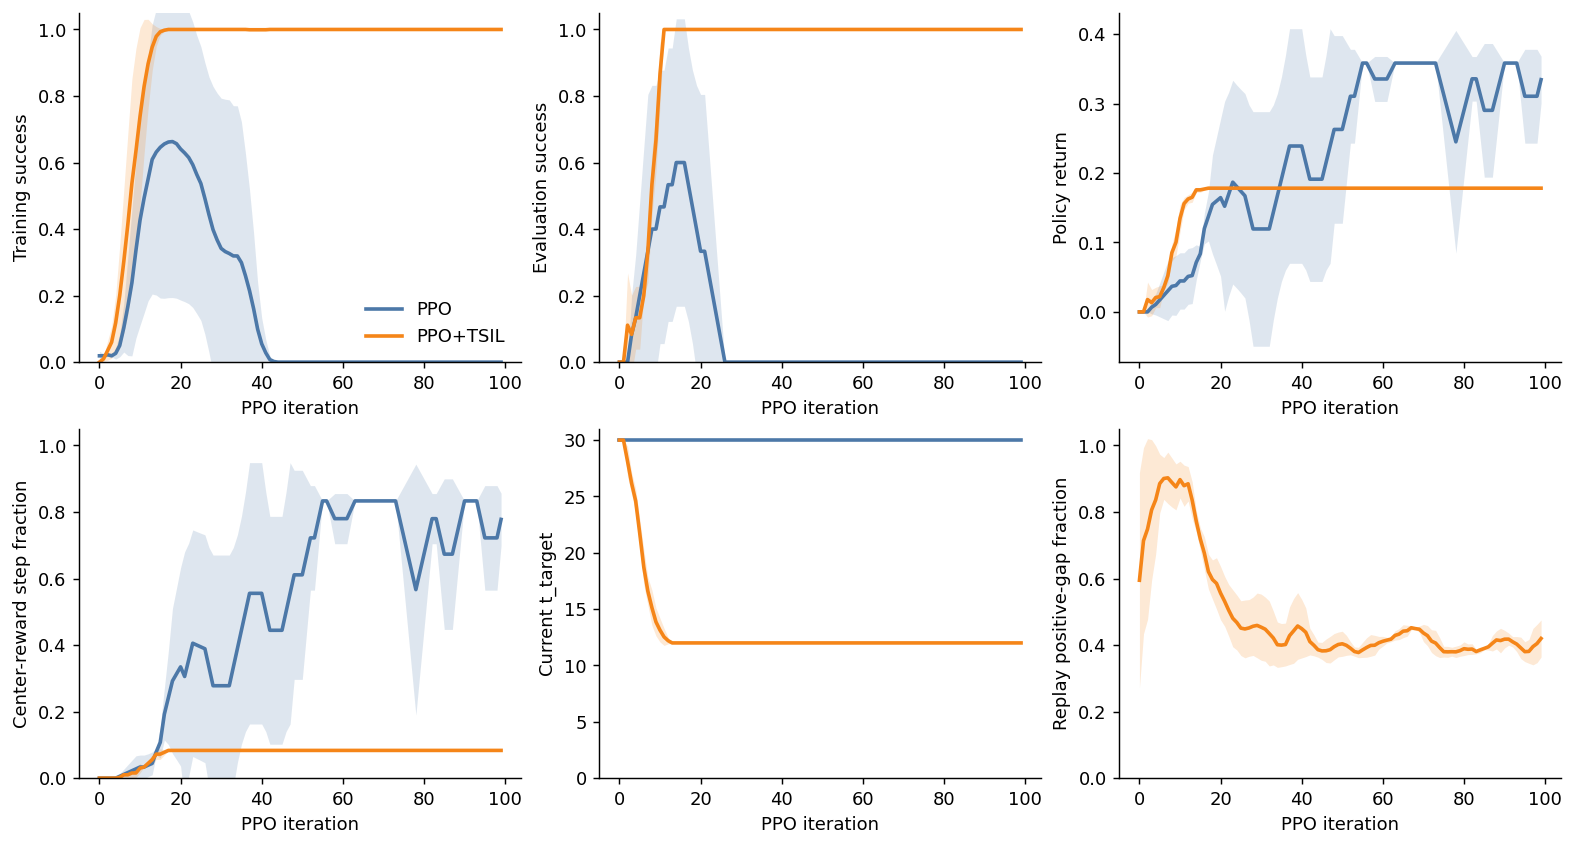

In [20]:
def rolling_mean(values, window=5):
    values = np.asarray(values, dtype=float)
    out = []
    for idx in range(len(values)):
        chunk = values[max(0, idx - window + 1) : idx + 1]
        out.append(np.nan if np.all(np.isnan(chunk)) else np.nanmean(chunk))
    return np.asarray(out)


def metric_array(method, key):
    return np.asarray([[entry[key] for entry in run["history"]] for run in runs[method]], dtype=float)


def nan_mean_std(arr):
    mask = ~np.isnan(arr)
    count = mask.sum(axis=0)
    total = np.where(mask, arr, 0.0).sum(axis=0)
    mean = np.divide(total, count, out=np.full(arr.shape[1], np.nan), where=count > 0)
    centered = np.where(mask, arr - mean, 0.0)
    var = np.divide((centered ** 2).sum(axis=0), count, out=np.zeros(arr.shape[1]), where=count > 0)
    return mean, np.sqrt(var)


def plot_metric(ax, key, ylabel, ylim=None):
    colors = {"PPO": "#4c78a8", "PPO+TSIL": "#f58518"}
    for method in METHODS:
        smoothed = np.asarray([rolling_mean(row) for row in metric_array(method, key)])
        mean, std = nan_mean_std(smoothed)
        x = np.arange(len(mean))
        ax.plot(x, mean, label=method, color=colors[method], linewidth=2)
        ax.fill_between(x, mean - std, mean + std, color=colors[method], alpha=0.18, linewidth=0)
    ax.set_xlabel("PPO iteration")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)


fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.4), constrained_layout=True)
plot_metric(axes[0, 0], "train_success", "Training success", (0, 1.05))
plot_metric(axes[0, 1], "eval_success", "Evaluation success", (0, 1.05))
plot_metric(axes[0, 2], "eval_policy_return", "Policy return")
plot_metric(axes[1, 0], "eval_dense_frac", "Center-reward step fraction", (0, 1.05))
plot_metric(axes[1, 1], "t_target", "Current t_target", (0, cfg.max_steps + 1))
plot_metric(axes[1, 2], "replay_positive_frac", "Replay positive-gap fraction", (0, 1.05))
axes[0, 0].legend(frameon=False)
plt.show()

These curves put the GIF in context. PPO tends to spend many evaluation steps collecting the center guidance reward, so its policy return can be high while task success remains poor.

PPO+TSIL uses the adaptive temporal target to turn successful rollouts into a self-paced temporal signal, then reinforces archived fast-success trajectories with positive-gap replay. In this demo, the temporal shaping term by itself still does not make fast success the highest scalar-return plan. TSIL instead biases the learning process toward efficient completion while keeping the task reward scale small.

This notebook isolates the core mechanism in a small maze. For more difficult long-horizon tasks, noisy training disturbances, and randomized configurations, please refer to the main benchmark experiments and paper results.

## 9. Questions & Answers

### Q1. Why is an adaptive temporal target better than a fixed temporal efficiency bonus?

A fixed temporal efficiency bonus can encourage faster success, for example

$$
r_t^{\mathrm{fixed}}
=
r_t^{\mathrm{task}}
+
\alpha
\frac{T_{\max}-t_{\mathrm{used}}}{T_{\max}}
\mathbf{1}_{\mathrm{succ}}.
$$

However, this heuristic requires task-specific calibration of both $T_{\max}$ and $\alpha$. If $T_{\max}$ is too large, the difference between fast and slow successes can become very small. If $T_{\max}$ is too small, the criterion becomes too strict and the temporal bonus can disappear for many successful trajectories.

ATTL instead uses the best previous successful behavior as a self-paced temporal reference:

$$
r_t^{\mathrm{temp}}
=
r_{\mathrm{succ}}
\min\left(\frac{t_{\mathrm{target}}}{t_{\mathrm{used}}}, 1\right)
\mathbf{1}_{\mathrm{succ}},
\qquad
t_{\mathrm{target}}
\leftarrow
\min(t_{\mathrm{target}}, T_{\mathrm{success}}).
$$

This makes the temporal reward depend on learning progress. A fixed $T_{\max}$-based bonus gives the same trajectory the same return early and late in training. With ATTL, the same trajectory is evaluated relative to the current temporal target. For example, a 20-step success receives the full temporal bonus when $t_{\mathrm{target}}=30$, but receives only $0.6r_{\mathrm{succ}}$ after the agent has already discovered a 12-step success. The criterion tightens as the policy improves, without manually redesigning the temporal scale for each task.

TSIL then strengthens this adaptive signal by storing and replaying fast-success trajectories through the archive and positive-gap replay loss.

### Q2. How do we ensure generalization to multiple configurations?

The toy maze uses one small configuration so the TSIL mechanisms are easy to inspect. In the full training setting, we use a large number of parallel simulation environments that cover many configurations during training. This exposes the policy to diverse task instances instead of optimizing for one fixed setup. In the paper, we also report evaluation results over 2000 random configurations.